In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Load Titanic Dataset directly from GitHub
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic_df = pd.read_csv(titanic_url)

print("Titanic Dataset Shape (rows, cols):", titanic_df.shape)

print("\nFirst Five Rows:")
print(titanic_df.head())

print("\nMissing Values:")
print(titanic_df.isnull().sum())

Titanic Dataset Shape (rows, cols): (891, 12)

First Five Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123   

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Select Features and Target
X_titanic = titanic_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
y_titanic = titanic_df['Survived']

# Handle Missing Age Values
X_titanic['Age'] = X_titanic['Age'].fillna(X_titanic['Age'].median())

# Encode Sex: male = 1, female = 0
label_encoder = LabelEncoder()
X_titanic['Sex'] = label_encoder.fit_transform(X_titanic['Sex'])

# Stratified Train-Test Split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)

print("Titanic Training Set Shape:", X_train_t.shape)
print("Titanic Test Set Shape:", X_test_t.shape)

Titanic Training Set Shape: (712, 6)
Titanic Test Set Shape: (179, 6)


In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Baseline Random Forest Classifier
rf_titanic = RandomForestClassifier(random_state=42)

# Initialize 10-Fold Stratified CV Strategy
cv_strategy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Compute Cross-Validation Scores
cv_scores = cross_val_score(
    rf_titanic,
    X_titanic,
    y_titanic,
    cv=cv_strategy,
    scoring='accuracy'
)

print("10-Fold Stratified CV Accuracy Scores:")
print(cv_scores.round(4))

print(f"\nMean Cross-Validation Accuracy Score: {cv_scores.mean() * 100:.2f}%")

print(f"Standard Deviation of CV Accuracy:     {cv_scores.std() * 100:.2f}%")

10-Fold Stratified CV Accuracy Scores:
[0.8333 0.8315 0.8315 0.7865 0.7753 0.8427 0.7978 0.7978 0.8315 0.8315]

Mean Cross-Validation Accuracy Score: 81.59%
Standard Deviation of CV Accuracy:     2.27%


In [5]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Run Grid Search Cross-Validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_t, y_train_t)

# Extract optimized model
best_rf_grid = grid_search.best_estimator_

# Predict on test set
grid_preds = best_rf_grid.predict(X_test_t)

# Calculate accuracy
grid_accuracy = accuracy_score(y_test_t, grid_preds)

print("Optimal Hyperparameters Selected via Grid Search:")
print(grid_search.best_params_)

print(f"\nGrid-Search Optimized Random Forest Test Accuracy: {grid_accuracy * 100:.2f}%")

Optimal Hyperparameters Selected via Grid Search:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}

Grid-Search Optimized Random Forest Test Accuracy: 80.45%


In [6]:
# Compile results
results = pd.DataFrame({
    'Method': [
        '10-Fold Stratified Cross-Validation',
        'Grid Search Optimized Random Forest'
    ],
    'Accuracy (%)': [
        cv_scores.mean() * 100,
        grid_accuracy * 100
    ]
})

print("\n--- K-Fold and Grid Search Comparison ---")
print(results.to_string(index=False))


--- K-Fold and Grid Search Comparison ---
                             Method  Accuracy (%)
10-Fold Stratified Cross-Validation     81.591760
Grid Search Optimized Random Forest     80.446927



--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



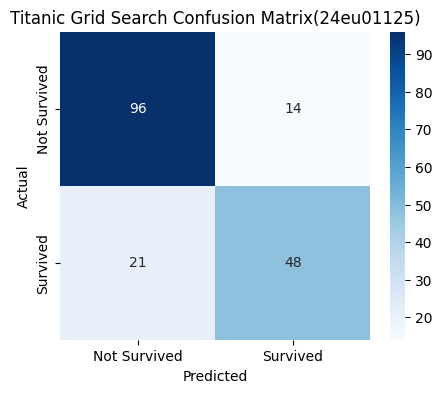

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Classification Report ---")
print(classification_report(y_test_t, grid_preds))

# Confusion Matrix
cm_titanic = confusion_matrix(y_test_t, grid_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_titanic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.title("Titanic Grid Search Confusion Matrix(24eu01125)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()